# 퍼널 및 리텐션 분석

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import platform

if platform.system() == 'Darwin':
    matplotlib.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    matplotlib.rc('font', family='Malgun Gothic')

matplotlib.rcParams['axes.unicode_minus'] = False

df_events = pd.read_csv('events.csv')
df_users  = pd.read_csv('users.csv')

print('이벤트:', df_events.shape)
print('유저:', df_users.shape)
df_events.head()

이벤트: (38524, 4)
유저: (9050, 3)


,user_id,product_id,event_date,event_type
0,AG3D6O4STAQKAY2UVGEUV46KN35Q,B07232M876,2023-03-22,view
1,AG3D6O4STAQKAY2UVGEUV46KN35Q,B074CWD7MS,2024-01-09,view
2,AG3D6O4STAQKAY2UVGEUV46KN35Q,B0B3G5XZN5,2023-07-19,view
3,AG3D6O4STAQKAY2UVGEUV46KN35Q,B0B3G5XZN5,2023-07-19,cart
4,AG3D6O4STAQKAY2UVGEUV46KN35Q,B017NC2IPM,2024-10-16,view


In [17]:
df_events.info()
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38524 entries, 0 to 38523
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     38524 non-null  object
 1   product_id  38524 non-null  object
 2   event_date  38524 non-null  object
 3   event_type  38524 non-null  object
dtypes: object(4)
memory usage: 1.2+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9050 entries, 0 to 9049
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     9050 non-null   object
 1   join_date   9050 non-null   object
 2   user_grade  9050 non-null   object
dtypes: object(3)
memory usage: 212.2+ KB


In [18]:
df_events['event_date'] = pd.to_datetime(df_events['event_date'])
df_users['join_date']   = pd.to_datetime(df_users['join_date'])

# 월 컬럼 추가 
df_events['year_month'] = df_events['event_date'].dt.to_period('M')

print(df_events.dtypes)
print()
print(df_events['year_month'].value_counts().sort_index().head())

user_id               object
product_id            object
event_date    datetime64[ns]
event_type            object
year_month         period[M]
dtype: object

year_month
2023-01    1643
2023-02    1576
2023-03    1681
2023-04    1651
2023-05    1685
Freq: M, Name: count, dtype: int64


## 퍼널 분석

In [19]:
funnel = df_events.groupby('event_type')['user_id'].nunique()

funnel_df = pd.DataFrame({
    '단계': ['조회(view)', '장바구니(cart)', '구매(purchase)'],
    '유저수': [funnel['view'], funnel['cart'], funnel['purchase']]
})

# 전환율 컬럼 추가
funnel_df['전환율(%)'] = (funnel_df['유저수'] / funnel_df['유저수'].iloc[0] * 100).round(1)

print(funnel_df)

             단계   유저수  전환율(%)
0      조회(view)  9050   100.0
1    장바구니(cart)  5551    61.3
2  구매(purchase)  2789    30.8


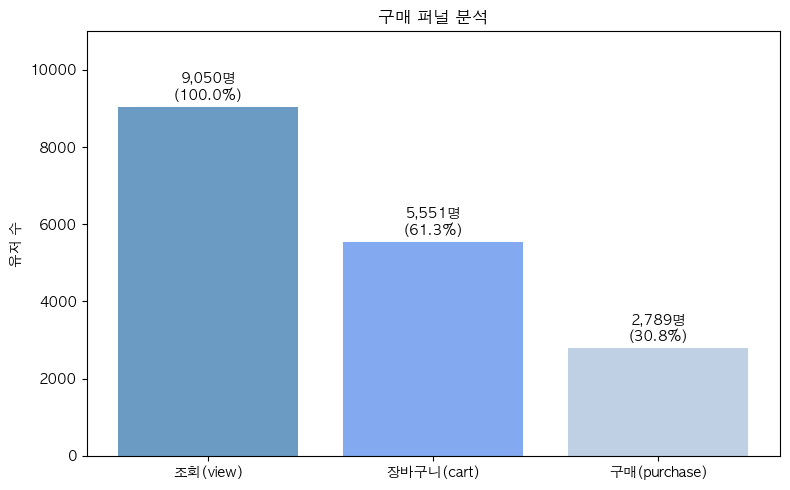

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['steelblue', 'cornflowerblue', 'lightsteelblue']
bars = ax.bar(funnel_df['단계'], funnel_df['유저수'], color=colors, alpha=0.8)

for bar, (_, row) in zip(bars, funnel_df.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 100,
            f"{row['유저수']:,}명\n({row['전환율(%)']:.1f}%)",
            ha='center', va='bottom', fontsize=10)

ax.set_ylabel('유저 수')
ax.set_title('구매 퍼널 분석')
ax.set_ylim(0, 11000)
plt.tight_layout()
plt.show()

합성 데이터 기준이므로 수치 해석보다 구조 파악만 해봄, 실제 데이터라면 이탈 원인까지 분석해 볼 수 있음

## 월별 구매 추이

In [21]:
df_purchase = df_events[df_events['event_type'] == 'purchase'].copy()

monthly = df_purchase.groupby('year_month')['user_id'].count().reset_index()
monthly.columns = ['year_month', '구매수']
monthly['year_month'] = monthly['year_month'].astype(str)

print(monthly.head())

  year_month  구매수
0    2023-01  152
1    2023-02  137
2    2023-03  155
3    2023-04  149
4    2023-05  131


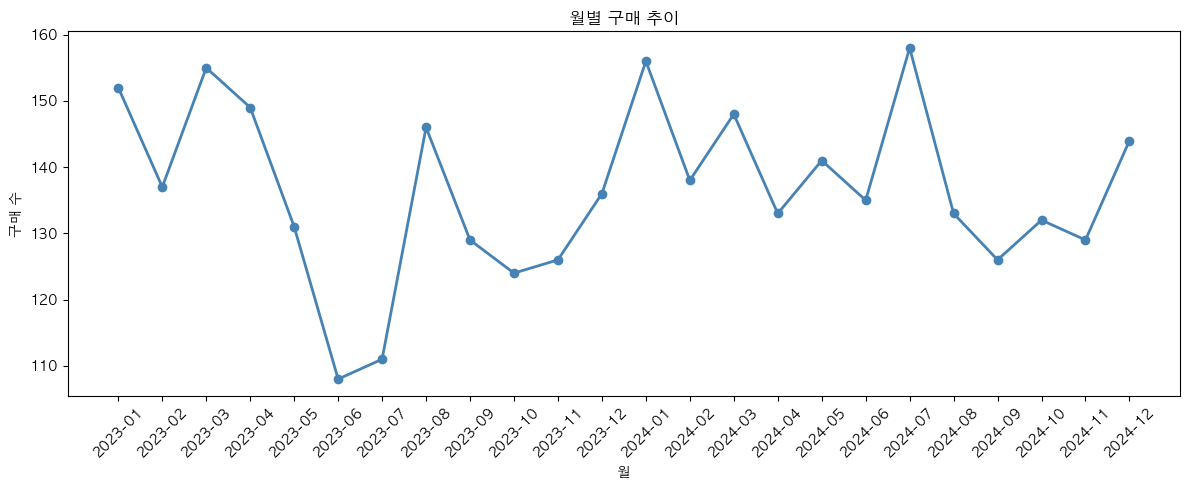

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(monthly['year_month'], monthly['구매수'], 
        marker='o', color='steelblue', linewidth=2)

ax.set_xlabel('월')
ax.set_ylabel('구매 수')
ax.set_title('월별 구매 추이')
ax.tick_params(axis='x', rotation=45)  
plt.tight_layout()
plt.show()

## 재구매율

In [23]:
purchase_count = df_purchase.groupby('user_id')['product_id'].count().reset_index()
purchase_count.columns = ['user_id', '구매횟수']

# 재구매자(2회 이상 구매)
repeat_buyers   = purchase_count[purchase_count['구매횟수'] >= 2]
one_time_buyers = purchase_count[purchase_count['구매횟수'] == 1]

total    = len(purchase_count)
repeat   = len(repeat_buyers)
one_time = len(one_time_buyers)

print(f"전체 구매자  : {total:,}명")
print(f"재구매자     : {repeat:,}명 ({repeat/total*100:.1f}%)")
print(f"1회 구매자   : {one_time:,}명 ({one_time/total*100:.1f}%)")
print()
print(purchase_count['구매횟수'].describe())

전체 구매자  : 2,789명
재구매자     : 443명 (15.9%)
1회 구매자   : 2,346명 (84.1%)

count    2789.000000
mean        1.174973
std         0.422049
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         4.000000
Name: 구매횟수, dtype: float64


84.1%라는 큰 비율이 1회 구매 후 이탈 -> 재구매 유도 전략 (알림, 알고리즘 추천) 이 필요함 !

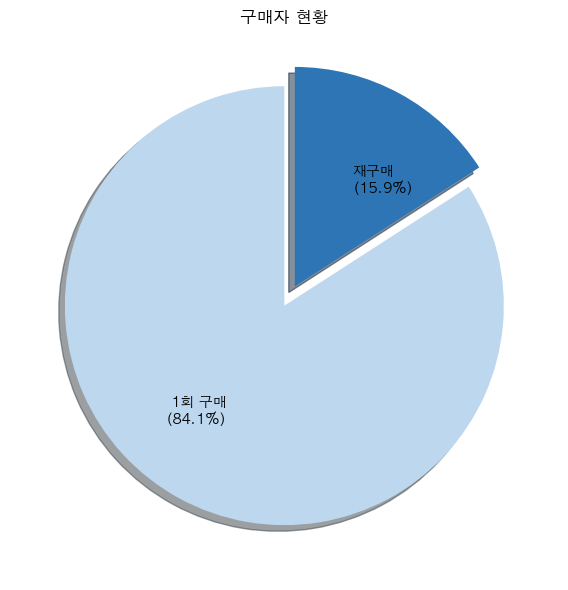

In [24]:
fig, ax = plt.subplots(figsize=(6, 6))

sizes  = [one_time, repeat]
colors = ['#BDD7EE', '#2E75B6'] 
explode = (0, 0.1)

labels = [f'1회 구매\n(84.1%)', f'재구매\n(15.9%)']

ax.pie(sizes, labels=labels, colors=colors,
       explode = explode,
       startangle=90,
       labeldistance=0.55,
       shadow = True,
       textprops={'fontsize': 10})

ax.set_title('구매자 현황')
plt.tight_layout()
plt.show()

# 코호트 분석

## 유저별 첫 구매 월

In [25]:
cohort_base = df_purchase.groupby('user_id')['year_month'].min().reset_index()
cohort_base.columns = ['user_id', 'cohort_month']

print(cohort_base.head())
print(f"\n코호트 수: {cohort_base['cohort_month'].nunique()}개월")

                        user_id cohort_month
0  AE22E2AXODSPNK3EBIHNGYS5LOSA      2023-11
1  AE23RS3W7GZO7LHYKJU6KSKVM4MQ      2024-07
2  AE243IWFZJ3BB6E6WMUG52DHWJVA      2023-03
3  AE27QPJRG7545VJX7LYRK2EO3I4Q      2024-07
4  AE2AQ2I2SHITDWZ4YERKOBFU4KGA      2023-03

코호트 수: 24개월


In [26]:
df_cohort = df_purchase.merge(cohort_base, on='user_id', how='left')

print(df_cohort[['user_id', 'year_month', 'cohort_month']].head())

                        user_id year_month cohort_month
0  AHCTC6ULH4XB6YHDY6PCH2R772LQ    2024-03      2024-03
1  AEQJHCVTNINBS4FKTBGQRQTGTE5Q    2023-03      2023-03
2  AFC3FFC5PKFF5PMA52S3VCHOZ5FQ    2024-10      2023-07
3  AFC3FFC5PKFF5PMA52S3VCHOZ5FQ    2023-07      2023-07
4  AH4QT33M55677I7ISQOAKEQWACYQ    2023-11      2023-11


In [27]:
df_cohort['cohort_index'] = (
    (df_cohort['year_month'].dt.to_timestamp() - 
     df_cohort['cohort_month'].dt.to_timestamp())
    .dt.days // 30
)

print(df_cohort[['user_id', 'year_month', 'cohort_month', 'cohort_index']].head(10))

                        user_id year_month cohort_month  cohort_index
0  AHCTC6ULH4XB6YHDY6PCH2R772LQ    2024-03      2024-03             0
1  AEQJHCVTNINBS4FKTBGQRQTGTE5Q    2023-03      2023-03             0
2  AFC3FFC5PKFF5PMA52S3VCHOZ5FQ    2024-10      2023-07            15
3  AFC3FFC5PKFF5PMA52S3VCHOZ5FQ    2023-07      2023-07             0
4  AH4QT33M55677I7ISQOAKEQWACYQ    2023-11      2023-11             0
5  AESFLDV2PT363T2AQLWQOWZ4N3OA    2024-05      2023-05            12
6  AESFLDV2PT363T2AQLWQOWZ4N3OA    2023-05      2023-05             0
7  AFDI6FRPFBTNBG7BAEB7JDJSMKDQ    2024-12      2024-12             0
8  AFQKCEEEKXCOHTDG4WUN3XPPHJQQ    2024-06      2024-06             0
9  AHKUUFNMBZIDLSSPA4FEHIO2EC7Q    2024-07      2024-07             0


In [28]:
cohort_pivot = df_cohort.groupby(
    ['cohort_month', 'cohort_index']
)['user_id'].nunique().reset_index()

cohort_pivot = cohort_pivot.pivot_table(
    index='cohort_month',
    columns='cohort_index',
    values='user_id'
)
cohort_pivot = cohort_pivot.fillna(0).astype(int)

print(cohort_pivot.iloc[:5, :6])

cohort_index    0  1  2  3  4  5
cohort_month                    
2023-01       149  3  0  1  2  0
2023-02       135  1  3  0  2  0
2023-03       149  1  2  3  0  3
2023-04       146  5  1  3  1  1
2023-05       118  1  1  0  0  1


In [29]:
cohort_pct = cohort_pivot.divide(cohort_pivot[0], axis=0) * 100
cohort_pct = cohort_pct.round(1)

print(cohort_pct.iloc[:5, :6])

cohort_index      0    1    2    3    4    5
cohort_month                                
2023-01       100.0  2.0  0.0  0.7  1.3  0.0
2023-02       100.0  0.7  2.2  0.0  1.5  0.0
2023-03       100.0  0.7  1.3  2.0  0.0  2.0
2023-04       100.0  3.4  0.7  2.1  0.7  0.7
2023-05       100.0  0.8  0.8  0.0  0.0  0.8


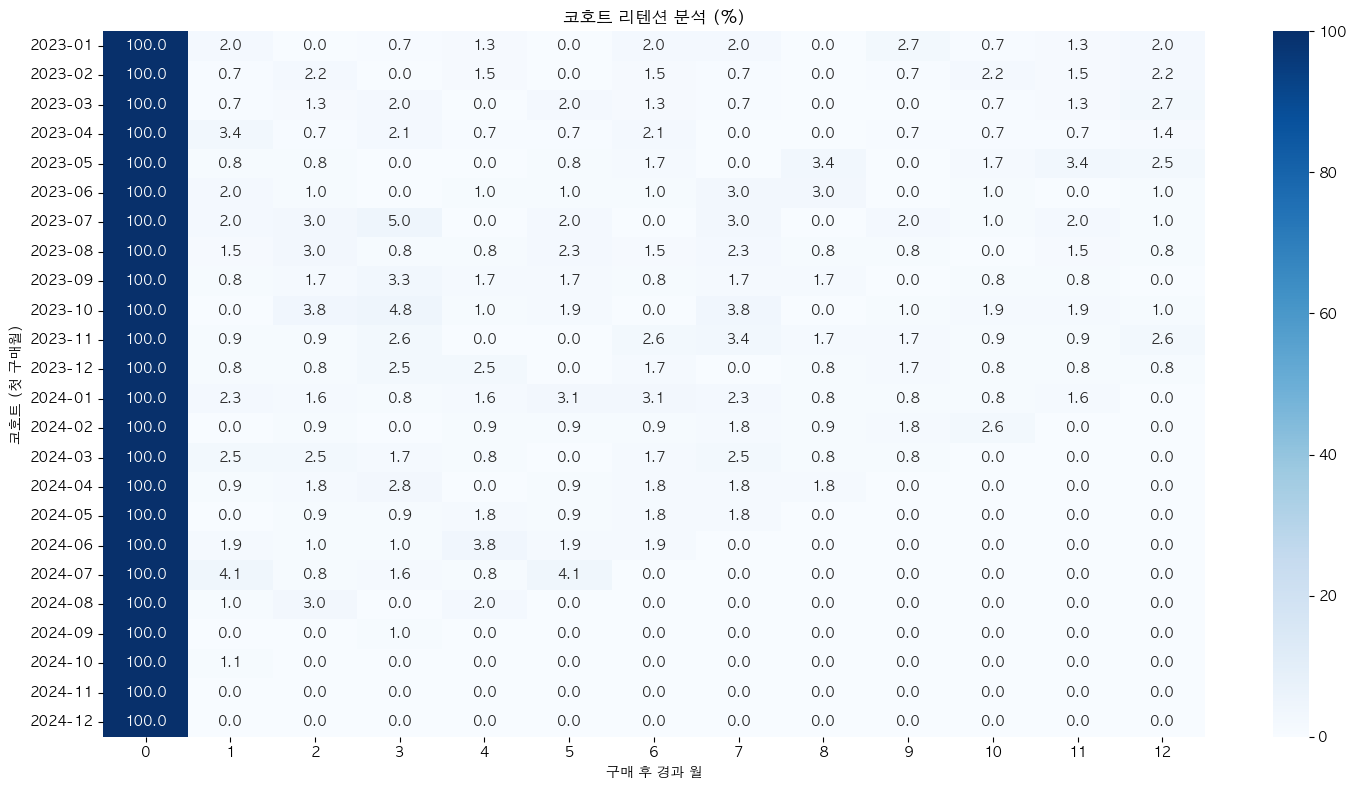

In [30]:
fig, ax = plt.subplots(figsize=(15, 8))

sns.heatmap(cohort_pct.iloc[:, :13],  
            annot=True,               
            fmt='.1f',                
            cmap='Blues',         
            ax=ax)

ax.set_title('코호트 리텐션 분석 (%)')
ax.set_xlabel('구매 후 경과 월')
ax.set_ylabel('코호트 (첫 구매월)')
plt.tight_layout()
plt.show()

합성 데이터 특성상 재구매가 균일하게 분포되어 코호트간 차이가 뚜렷하진 않음 